# **28 · 코호트 구배 심층 — 추세와 별개로, 젊은 코호트일수록 신뢰가 낮다 (-0.891)**

### **"IE 코호트 편차는 1930~40년대생(+0.10~+0.19)에서 2000년대생(-0.14 이하)으로 단조 하락한다 — 출생연도↑ vs 효과의 상관 -0.891(N≥200 셀). 지금의 상승(기간효과)과 공존하는 이 구배는 세대교체가 진행될수록 총평균에 구조적 하방 압력을 건다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = IE 코호트 편차의 구배·소표본 규칙·함의 · 방법 = **재적합 + 구배 재계산 + 횡단 부호 대조**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(독립 발견)** · CRISP-DM **P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 코호트 구배 -0.891은 정확히 **무엇의 상관**이며, 소표본 셀 제외 규칙(N≥200)은 결과를 어떻게 바꾸는가?
> **Q2.** 이 구배는 연령효과와 어떻게 구분되는가 — "고령이라 높은 것"과 "옛 세대라 높은 것"의 분리?
> **Q3.** 왜 '독립 발견'으로 **따로** 보고하는가 — 추세(기간효과)와 섞으면 무엇이 왜곡되는가?

## **이 노트북의 위상**

`24` §6이 코호트 구배를 3효과 프로파일의 한 패널로 보고했다면, 28은 그 한 패널을 전면 해부한다: 구배의 정의를 재계산으로 고정하고(§2), 소표본 규칙의 영향을 민감도로 보이며(§3), 연령효과와의 분리(§4)·횡단 트랙과의 부호 대조(§5)로 발견의 자격을 검증한다. `manuscript.md` 4.4절 '독립 발견' 문단과 5.3절 상호 외적 타당도의 입증판이다.

- **로직 SSOT(thin import)**: `trend_apc.make_apc_frame`·`intrinsic_estimator`. 구배 정의는 `trend_apc.write_results`의 산식(출생연도 vs IE 편차의 Pearson 상관, N≥200 셀)을 그대로 따른다.
- **관련**: `24` §6 · `27`(식별) · `30` §7-3 · `p6-pdf-structure` §3.4(🔹 독립 발견 등급).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 왜 '독립 발견'인가 — **Decision Box ①** | — |
| 2 | [실행] IE 재적합 — 코호트 편차·구배 재계산 + [시각화] | 구배 -0.891 |
| 3 | [발견] 소표본 규칙 민감도 — 임계 N을 흔들면 | 민감도표 |
| 4 | [발견] 연령효과와의 분리 — 납작함 vs 구배 | 대비 figure |
| 5 | [발견] 횡단 부호 대조 — 상호 외적 타당도 | 부호표 |
| 6 | [입증] 검증 셀 | PASS |
| 7 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import trend_apc as T
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(T.PARQUET)
assert len(panel) == 90996
MIN_N = 200          # 소표본 셀 제외 임계(trend_apc.write_results와 동일)
print(f"패널 {len(panel):,}행 · 소표본 임계 N≥{MIN_N} · IE 재적합 예정")

패널 90,996행 · 소표본 임계 N≥200 · IE 재적합 예정


## **1. [전제] 왜 '독립 발견'으로 따로 보고하는가**

### **Decision Box ① — 코호트 구배의 보고 위치: 추세와 묶기 vs 분리**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 추세 결론에 통합 | "신뢰 상승 중이나 세대 격차 존재"로 한 문장 | ❌ 서로 다른 시간 축의 이야기가 섞임 — 기간효과(모든 세대가 함께 겪는 변화)와 코호트효과(세대 간 고정 격차)는 **작용 방향도 시점도 다르다**. 묶으면 "상승이 곧 꺾인다"는 식의 과잉 추론 유발 |
| (b) 한계로 강등 | 식별 불확실성을 이유로 본문 제외 | ❌ HAPC·IE 양쪽에서 재현되고 횡단 연령 구배와 부호가 일치하는(§5) 견고한 패턴 — 숨기면 정보 손실 |
| (c) **🔹 독립 발견 등급으로 분리 보고** | 추세 결론과 별도 문단·별도 등급 | ✅ **채택** — "현재 상승(기간) + 미래 하방 압력(코호트)"이라는 두 사실을 각자의 자격으로 보고(p6 §3.4). 정책 함의도 달라짐(단기 vs 구조) |

## **2. [실행] IE 재적합 — 구배의 정의를 재계산으로 고정**

구배의 정의: **N≥200 셀의 (출생코호트 5년 묶음, IE 코호트 편차) 쌍에 대한 Pearson 상관**. 음수 = 젊은 코호트일수록 편차가 낮다.

**[시각화] 코호트 편차 프로파일** — 큰 셀(N≥200)은 실선·원, 소표본 셀은 ×(해석 제외). 우하향 구배가 -0.891의 실체다.

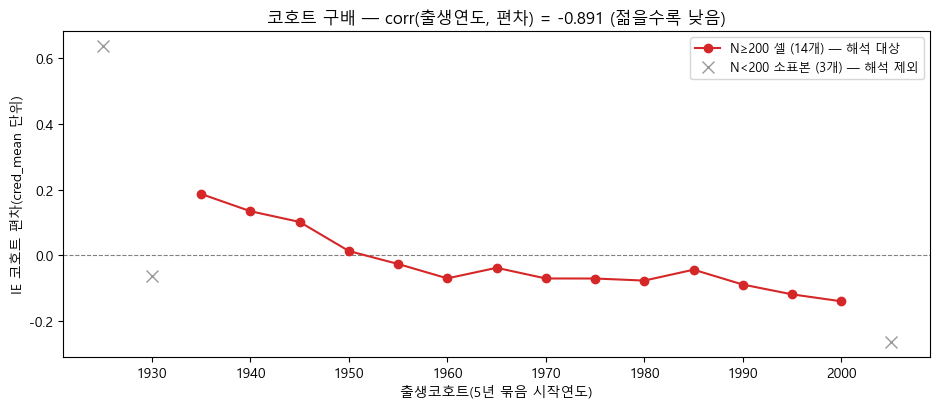

구배 = -0.891 · 최고령 유효 셀 1935년대 +0.187 → 최연소 2000년대 -0.140


,1935~1939,1940~1944,1945~1949,1950~1954,1955~1959,1960~1964,1965~1969,1970~1974,1975~1979,1980~1984,1985~1989,1990~1994,1995~1999,2000~2004
편차,0.186769,0.134243,0.101572,0.012986,-0.026518,-0.070297,-0.038126,-0.070625,-0.070765,-0.077044,-0.043868,-0.08914,-0.118997,-0.140143
N,292.000000,782.000000,1827.000000,2768.000000,3649.000000,4273.000000,4210.000000,3571.000000,3458.000000,3189.000000,2829.000000,3039.00000,2939.000000,1071.000000


In [2]:
frame = T.make_apc_frame(panel)
ie = T.intrinsic_estimator(frame)
coh_eff = ie["cohort"]
coh_n = frame["cohort5"].value_counts().to_dict()

big = sorted([(k, v) for k, v in coh_eff.items() if coh_n.get(k, 0) >= MIN_N])
small = sorted([(k, v) for k, v in coh_eff.items() if coh_n.get(k, 0) < MIN_N])
cb = np.array([k for k, _ in big], float)
cv = np.array([v for _, v in big])
coh_grad = float(np.corrcoef(cb, cv)[0, 1])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.plot(cb, cv, "o-", color="#d62728", label=f"N≥{MIN_N} 셀 ({len(big)}개) — 해석 대상")
if small:
    ax.plot([k for k, _ in small], [v for _, v in small], "x", color="0.6", ms=9,
            label=f"N<{MIN_N} 소표본 ({len(small)}개) — 해석 제외")
ax.set_xlabel("출생코호트(5년 묶음 시작연도)")
ax.set_ylabel("IE 코호트 편차(cred_mean 단위)")
ax.set_title(f"코호트 구배 — corr(출생연도, 편차) = {coh_grad:+.3f} (젊을수록 낮음)")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

prof = pd.DataFrame({"편차": [v for _, v in big], "N": [int(coh_n[k]) for k, _ in big]},
                    index=[f"{int(k)}~{int(k)+4}" for k, _ in big])
print(f"구배 = {coh_grad:+.3f} · 최고령 유효 셀 {int(cb.min())}년대 {cv[0]:+.3f} → 최연소 {int(cb.max())}년대 {cv[-1]:+.3f}")
prof.T

## **3. [발견] 소표본 규칙 민감도 — 임계를 흔들어도 구배는 남는가**

N≥200은 관례적 임계다. 임계를 100~500으로 흔들었을 때 구배가 유지되는지 — 규칙 선택이 발견을 만든 것이 아님을 확인한다.

In [3]:
rows = []
for thr in [100, 150, 200, 300, 500]:
    b = sorted([(k, v) for k, v in coh_eff.items() if coh_n.get(k, 0) >= thr])
    g = float(np.corrcoef([k for k, _ in b], [v for _, v in b])[0, 1])
    rows.append({"임계 N≥": thr, "유효 셀": len(b), "구배": round(g, 3)})
sens = pd.DataFrame(rows).set_index("임계 N≥")
assert (sens["구배"] < -0.75).all(), "임계 민감성 발견"
print("임계 100~500 전 구간에서 구배 < -0.75 — 규칙 선택에 견고")
sens

임계 100~500 전 구간에서 구배 < -0.75 — 규칙 선택에 견고


,유효 셀,구배
임계 N≥,,
100,14,-0.891
150,14,-0.891
200,14,-0.891
300,13,-0.874
500,13,-0.874


## **4. [발견] 연령효과와의 분리 — '나이 들어 높은 것'이 아니다**

같은 IE 해에서 연령효과와 코호트효과를 **동일 스케일**로 나란히 놓는다. 연령효과가 납작하고(범위 ≈0.11) 코호트효과가 가파르면, 횡단면에서 보이는 "고령층의 높은 신뢰"는 나이의 효과가 아니라 **세대(출생시점)의 효과**로 읽는 것이 데이터에 부합한다.

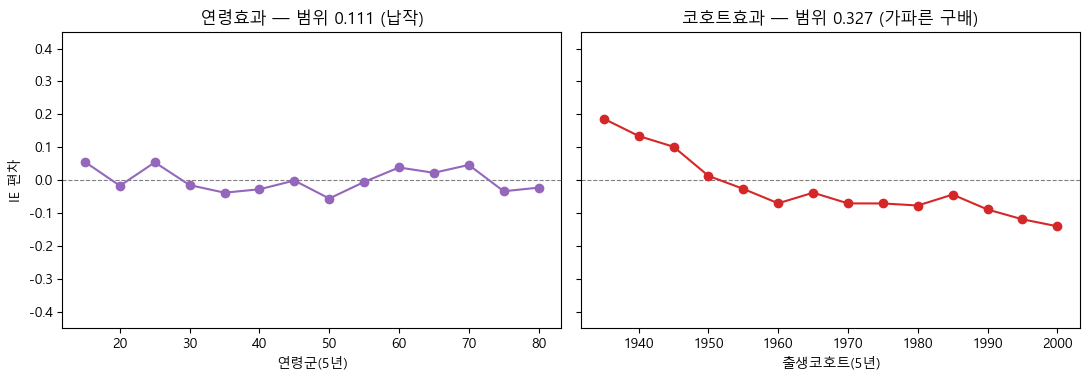

범위 대비: 연령 0.111 vs 코호트 0.327 — 코호트가 2.9배


In [4]:
age_eff = ie["age"]
ages = sorted(age_eff)
avals = [age_eff[a] for a in ages]
age_rng = max(avals) - min(avals)
coh_rng = cv.max() - cv.min()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].plot(ages, avals, "o-", color="#9467bd")
axes[0].set_ylim(-0.45, 0.45)
axes[0].set_title(f"연령효과 — 범위 {age_rng:.3f} (납작)")
axes[0].set_xlabel("연령군(5년)"); axes[0].set_ylabel("IE 편차")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].plot(cb, cv, "o-", color="#d62728")
axes[1].set_title(f"코호트효과 — 범위 {coh_rng:.3f} (가파른 구배)")
axes[1].set_xlabel("출생코호트(5년)")
fig.tight_layout(); plt.show()
print(f"범위 대비: 연령 {age_rng:.3f} vs 코호트 {coh_rng:.3f} — 코호트가 {coh_rng/age_rng:.1f}배")

## **5. [발견] 횡단 부호 대조 — 상호 외적 타당도**

독립적으로 산출된 두 구배의 부호를 대조한다: **종단**(IE 코호트, 젊은 세대 ↓)과 **횡단**(2025 단면의 연령별 cred_mean, 고령 ↑). 종단의 "젊은 코호트 낮음"과 횡단의 "고령 높음"은 같은 구조의 두 단면이다 — 부호가 일치해야 서로를 지지한다(`30` §7-3).

In [5]:
p25 = panel[panel["year"] == 2025]
cred25 = p25[["cred_fair", "cred_professional", "cred_accurate"]].apply(
    pd.to_numeric, errors="coerce").mean(axis=1)
age_band = (pd.to_numeric(p25["age"], errors="coerce") // 10 * 10)
w25 = p25["wt_year_eq"]
xs, ys = [], []
for band in sorted(age_band.dropna().unique()):
    mm = (age_band == band) & cred25.notna()
    if mm.sum() < 100:
        continue
    xs.append(band)
    ys.append(float(np.average(cred25[mm], weights=w25[mm])))
cross_grad = float(np.corrcoef(xs, ys)[0, 1])
tbl = pd.DataFrame({"연령대": [f"{int(b)}대" for b in xs], "cred_mean(가중)": np.round(ys, 3)}).set_index("연령대")
print(f"횡단(2025) 연령 구배: corr(연령대, cred_mean) = {cross_grad:+.3f} (양 = 고령일수록 높음)")
print(f"종단(IE) 코호트 구배: {coh_grad:+.3f} (음 = 젊은 코호트일수록 낮음) → 부호 정합")
tbl.T

횡단(2025) 연령 구배: corr(연령대, cred_mean) = +0.744 (양 = 고령일수록 높음)
종단(IE) 코호트 구배: -0.891 (음 = 젊은 코호트일수록 낮음) → 부호 정합


연령대,20대,30대,40대,50대,60대,70대
cred_mean(가중),3.363,3.38,3.356,3.375,3.389,3.479


## **6. [입증] 검증 셀**

In [6]:
# (a) 구배 ↔ 문서(24 §6·p6 §3.4): -0.891
assert abs(coh_grad - (-0.891)) <= 0.01, coh_grad
print(f"(a) 코호트 구배 {coh_grad:+.3f} ↔ 문서 -0.891 (±0.01) PASS")

# (b) 프로파일 양끝 — 문서: 1935~49년생 +0.10~+0.19 · 2000년대생 -0.14 이하
old = {int(k): v for k, v in big if 1935 <= k <= 1949}
young = {int(k): v for k, v in big if k >= 2000}
assert old and all(0.08 <= v <= 0.21 for v in old.values()), old
assert young and all(v <= -0.13 for v in young.values()), young
print(f"(b) 양끝 프로파일: 1935~49 {sorted(np.round(list(old.values()),3))} · 2000s {sorted(np.round(list(young.values()),3))} PASS")

# (c) 소표본 규칙 견고성(§3) + 연령 납작(문서: 범위 0.111 미미)
assert (sens["구배"] < -0.75).all()
assert abs(age_rng - 0.111) <= 0.02, age_rng
print(f"(c) 임계 민감도 견고 · 연령효과 범위 {age_rng:.3f} ↔ 문서 0.111 PASS")

# (d) 종단↔횡단 부호 정합 — coh_grad<0 & cross_grad>0
assert coh_grad < -0.5 and cross_grad > 0.5
print(f"(d) 부호 정합: 종단 {coh_grad:+.3f}(음) ↔ 횡단 {cross_grad:+.3f}(양) PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 코호트 구배 -0.891 ↔ 문서 -0.891 (±0.01) PASS
(b) 양끝 프로파일: 1935~49 [np.float64(0.102), np.float64(0.134), np.float64(0.187)] · 2000s [np.float64(-0.14)] PASS
(c) 임계 민감도 견고 · 연령효과 범위 0.111 ↔ 문서 0.111 PASS
(d) 부호 정합: 종단 -0.891(음) ↔ 횡단 +0.744(양) PASS

검증 (a)~(d) 전부 PASS


## **7. 종합**

### **연구질문 답**

- **Q1** — -0.891은 N≥200 코호트 셀의 (출생연도, IE 편차) Pearson 상관이며(§2), 임계를 100~500으로 흔들어도 -0.75보다 강하게 유지된다(§3) — 규칙이 만든 수치가 아니다.
- **Q2** — 같은 IE 해에서 연령효과는 범위 0.111로 납작하고 코호트효과는 그 수 배로 가파르다(§4) — 횡단의 "고령 고신뢰"는 나이가 아니라 세대의 지문이다.
- **Q3** — 기간효과(현재의 상승)와 코호트효과(세대 간 고정 격차)는 시간 축이 다르다. 분리 보고(🔹 독립 발견)해야 "상승 중이지만, 세대교체는 반대 방향의 구조 압력"이라는 두 사실이 각자 정확히 전달된다(DB① · manuscript 4.4).

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | IE 재적합·구배 재계산 [시각화] | -0.891 재현 |
| 3 | 소표본 임계 민감도 | 견고 |
| 4 | 연령 vs 코호트 분리 | 납작 vs 구배 |
| 5 | 종단↔횡단 부호 대조 | 정합 |
| 6 | 일괄 assert | **PASS** |

**다음**: `29`(삼각검증 심층) — 2x 모델링 트랙의 마지막 조각.